In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df_tc = pd.read_csv('tc/tc_results.csv')

graph_info_tc = {
    'soc-LiveJournal1.mtx': {'edges': 68993773, 'type': 'Power-Law'},
    'roadNet-CA.mtx': {'edges': 5533214, 'type': 'Road Network'},
    'rgg_n_2_22_s0.mtx': {'edges': 33554432, 'type': 'Random Geometric'}
}

hue_order = ['LAGraph', 'SPLA']
graph_order = ['rgg_n_2_22_s0.mtx', 'roadNet-CA.mtx', 'soc-LiveJournal1.mtx']

df_tc_clean = df_tc[df_tc['IterType'] != 'Warmup'].copy()

def get_stats(group):
    data = group['Time_ms']
    n = len(data)
    mean = np.mean(data)
    std_err = stats.sem(data)
    p_val = stats.shapiro(data)[1] if n >= 3 else np.nan
    ci = stats.t.interval(0.95, n-1, loc=mean, scale=std_err)
    return pd.Series({
        'Mean_ms': mean,
        'Median_ms': np.median(data),
        'CI_lower': ci[0],
        'CI_upper': ci[1],
        'Std_Err': std_err,
        'P_Normal': p_val
    })

def calc_tc_gteps(row):
    if row['Graph'] in graph_info_tc:
        edges = graph_info_tc[row['Graph']]['edges']
        return edges / (row['Mean_ms'] * 1e6)
    return 0

df_tc_stats = df_tc_clean.groupby(['Graph', 'Library']).apply(get_stats).reset_index()
df_tc_stats['GTEPS'] = df_tc_stats.apply(calc_tc_gteps, axis=1)
df_tc_stats['Graph'] = pd.Categorical(df_tc_stats['Graph'], categories=graph_order, ordered=True)
df_tc_stats['Library'] = pd.Categorical(df_tc_stats['Library'], categories=hue_order, ordered=True)
df_tc_stats = df_tc_stats.sort_values(['Graph', 'Library'])

print("Normality test (p < 0.05):")
print(df_tc_stats[['Graph', 'Library', 'P_Normal']])

Normality test (p < 0.05):
                  Graph  Library      P_Normal
0     rgg_n_2_22_s0.mtx  LAGraph  2.191203e-14
1     rgg_n_2_22_s0.mtx     SPLA  8.474723e-01
2        roadNet-CA.mtx  LAGraph  1.081919e-15
3        roadNet-CA.mtx     SPLA  1.767566e-01
4  soc-LiveJournal1.mtx  LAGraph  1.710482e-13
5  soc-LiveJournal1.mtx     SPLA  9.037599e-04


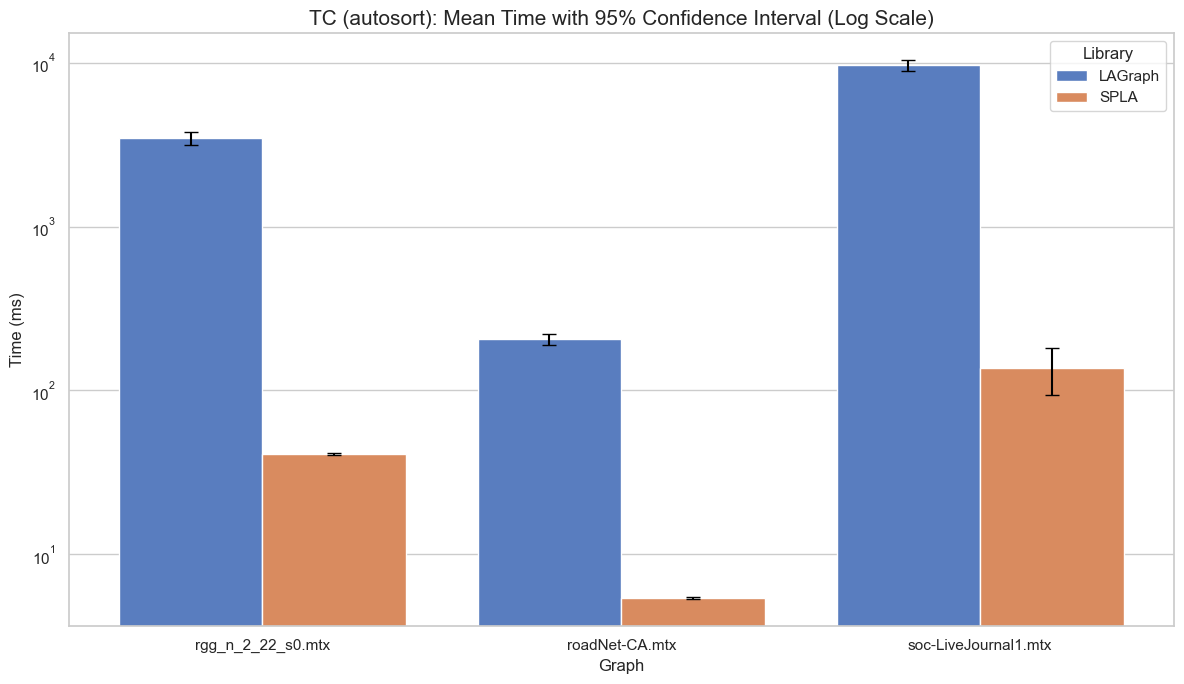

In [68]:
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df_tc_stats, 
    x='Graph', 
    y='Mean_ms', 
    hue='Library', 
    order=graph_order, 
    hue_order=hue_order, 
    palette='muted'
)

bars = sorted([p for p in ax.patches if p.get_height() > 0], key=lambda x: x.get_x())

x_coords = [p.get_x() + p.get_width() / 2. for p in bars]
y_coords = [p.get_height() for p in bars]

lower_err = df_tc_stats['Mean_ms'] - df_tc_stats['CI_lower']
upper_err = df_tc_stats['CI_upper'] - df_tc_stats['Mean_ms']
yerr = [lower_err.values, upper_err.values]

plt.errorbar(x=x_coords, y=y_coords, yerr=yerr, fmt='none', c='black', capsize=5, elinewidth=1.5)

plt.title('TC (autosort): Mean Time with 95% Confidence Interval (Log Scale)', fontsize=15)
plt.ylabel('Time (ms)')
plt.yscale('log')

plt.tight_layout()
plt.savefig("tc/mean_time.png")
plt.show()

/var/folders/hk/lfdr9_h57c9d_kj4145634h40000gn/T/ipykernel_75057/2627334495.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=pivot_tc, x='Graph', y='Speedup', palette='magma', legend=False)


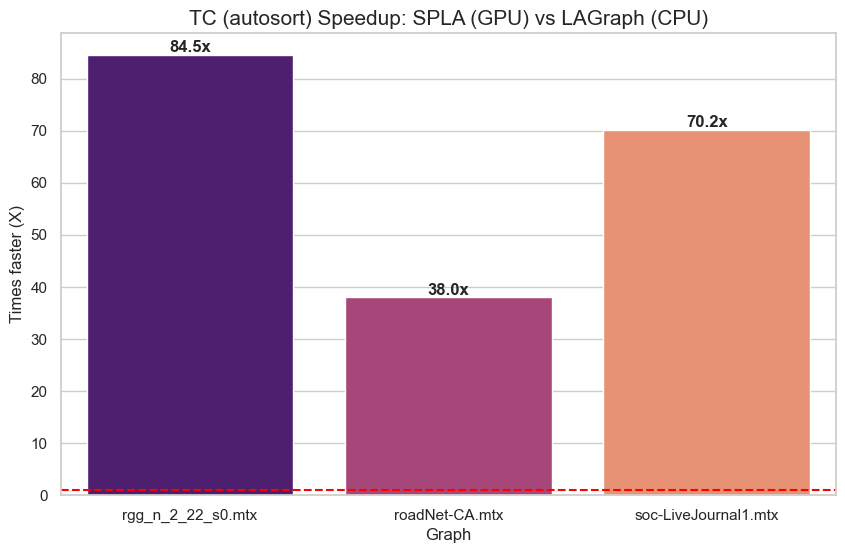

In [69]:
pivot_tc = df_tc_stats.pivot(index='Graph', columns='Library', values='Mean_ms')
pivot_tc['Speedup'] = pivot_tc['LAGraph'] / pivot_tc['SPLA']
pivot_tc = pivot_tc.reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=pivot_tc, x='Graph', y='Speedup', palette='magma', legend=False)

plt.axhline(1.0, color='red', linestyle='--', label='Baseline (CPU)')
plt.title('TC (autosort) Speedup: SPLA (GPU) vs LAGraph (CPU)', fontsize=15)
plt.ylabel('Times faster (X)')

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f') + 'x', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'bottom', fontsize=12, fontweight='bold')

plt.savefig("tc/time_speedup.png")
plt.show()

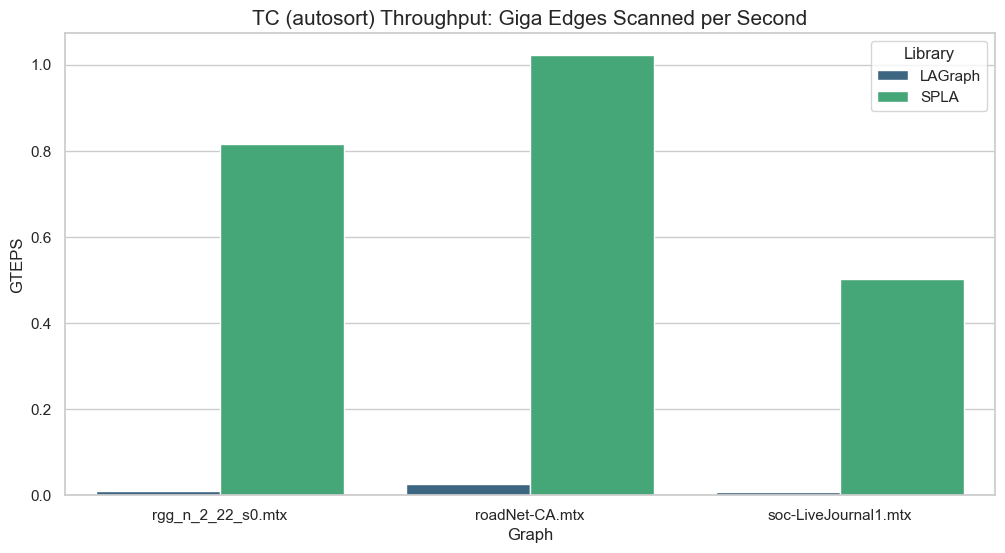

In [63]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df_tc_stats, x='Graph', y='GTEPS', hue='Library', palette='viridis')

plt.title('TC (autosort) Throughput: Giga Edges Scanned per Second', fontsize=15)
plt.ylabel('GTEPS')
plt.show()

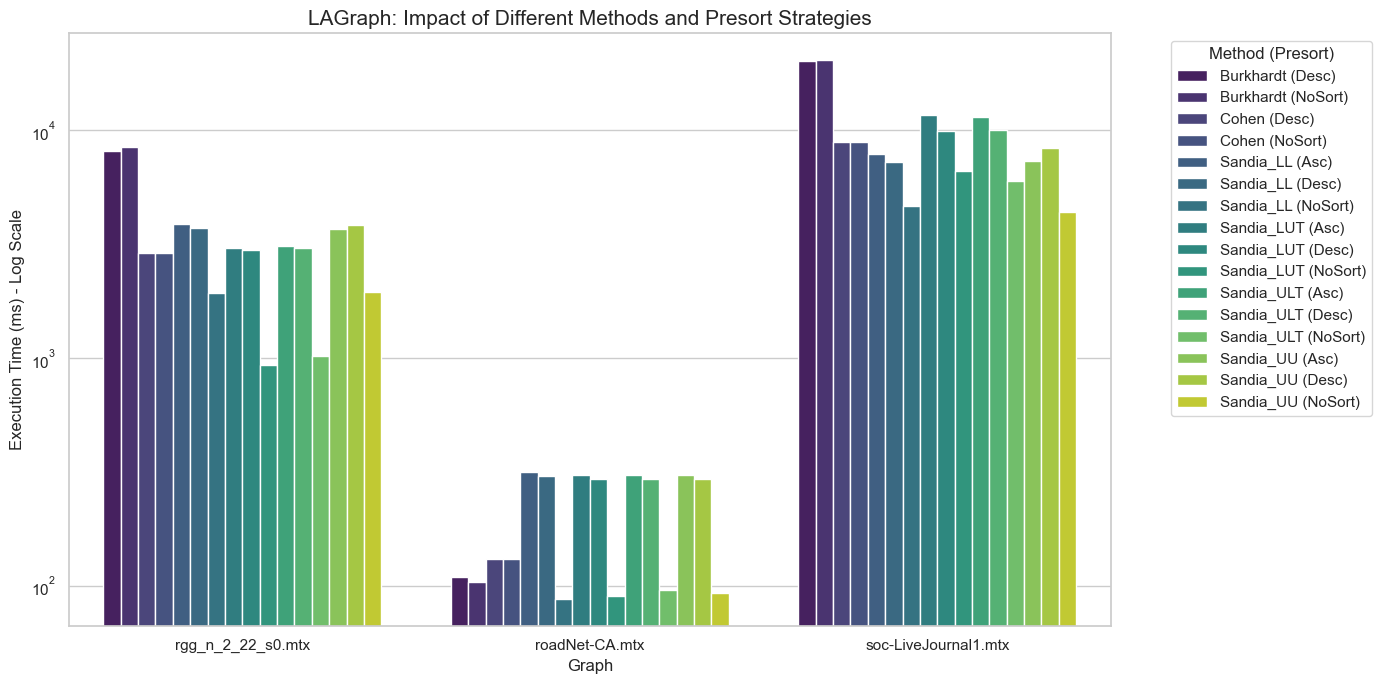

In [74]:
df_methods = df_tc_clean.groupby(['Graph', 'Library', 'Method', 'Sort'])['Time_ms'].median().reset_index()
df_methods['Config'] = df_methods['Method'] + " (" + df_methods['Sort'] + ")"

plt.figure(figsize=(14, 7))
ax = sns.barplot(data=df_methods[df_methods['Library'] == 'LAGraph'], x='Graph', y='Time_ms', hue='Config', palette='viridis')
plt.yscale('log')
plt.title('LAGraph: Impact of Different Methods and Presort Strategies', fontsize=15)
plt.ylabel('Execution Time (ms) - Log Scale')
plt.legend(title='Method (Presort)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("tc/methods_time.png")
plt.show()

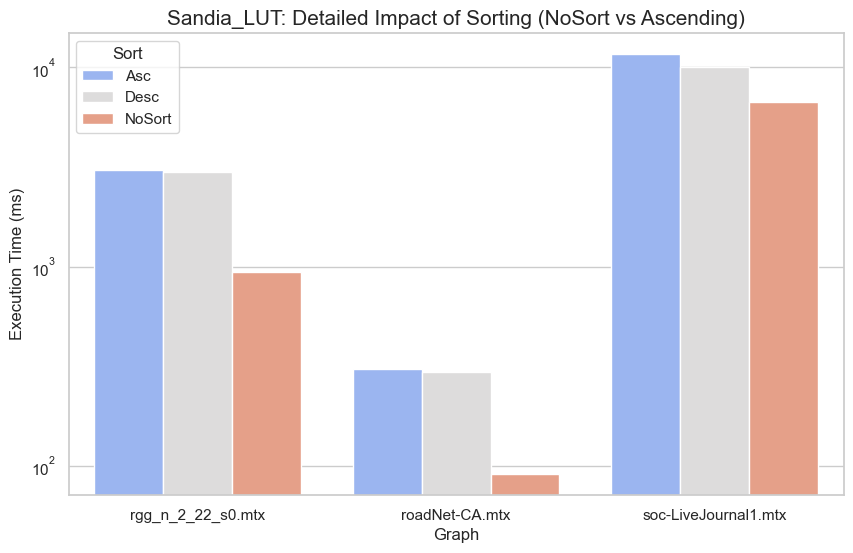

In [73]:
df_sandia = df_methods[df_methods['Method'] == 'Sandia_LUT'].copy()
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_sandia, x='Graph', y='Time_ms', hue='Sort', palette='coolwarm')
plt.yscale('log')
plt.title('Sandia_LUT: Detailed Impact of Sorting (NoSort vs Ascending)', fontsize=15)
plt.ylabel('Execution Time (ms)')
plt.savefig("tc/sandia_lut_methods_time.png")
plt.show()

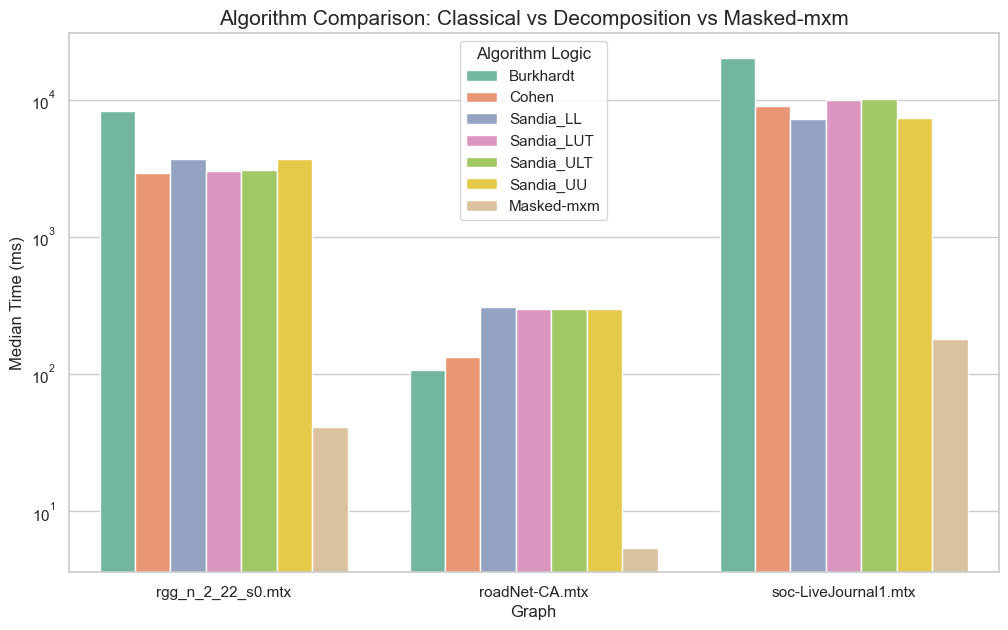

In [72]:
df_comparison = df_tc_clean.groupby(['Graph', 'Library', 'Method'])['Time_ms'].median().reset_index()
plt.figure(figsize=(12, 7))
ax = sns.barplot(data=df_comparison, x='Graph', y='Time_ms', hue='Method', palette='Set2')
plt.yscale('log')
plt.title('Algorithm Comparison: Classical vs Decomposition vs Masked-mxm', fontsize=15)
plt.ylabel('Median Time (ms)')
plt.legend(title='Algorithm Logic')
plt.savefig("tc/median_methods.png")
plt.show()